Import libraries:

In [1]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import shap

f:\Stuff\School\UWaterloo\spring 2026\stat 444\Pharmaceutical Investment Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import cleaned data:

In [10]:
df = pd.read_csv('clinical_trials_cleaned.csv', parse_dates=['start_date', 'completion_date'])
categorical_cols = ['phase', 'sponsor_type', 'allocation', 'intervention_model', 
                    'masking', 'primary_purpose', 'gender', 'healthy_volunteers']
for col in categorical_cols:
    df[col] = df[col].astype('category')
df.shape

(114663, 20)

Data descriptives:

In [11]:
print(df['duration_days'].describe())

count    114663.000000
mean       1011.577649
std         966.553126
min           1.000000
25%         335.000000
50%         731.000000
75%        1400.000000
max       23042.000000
Name: duration_days, dtype: float64


In [12]:
print(df['phase'].value_counts())

phase
PHASE2           30605
PHASE1           27641
PHASE3           23632
PHASE4           19691
PHASE1/PHASE2     6940
PHASE2/PHASE3     3623
EARLY_PHASE1      2531
Name: count, dtype: int64


In [13]:
print(df['sponsor_type'].value_counts())

sponsor_type
INDUSTRY     55968
OTHER        51974
NIH           2782
OTHER_GOV     1676
NETWORK       1243
FED            812
INDIV          174
UNKNOWN         34
Name: count, dtype: int64


Train-test split:

This data is based on time, so we will use a chronological split:

In [14]:
split_date = pd.Timestamp('2019-01-01') # chosen such that the training set is about 80% of the data
train = df[df['start_date'] < split_date]
test = df[df['start_date'] >= split_date]
print(train.shape, test.shape)

(89153, 20) (25510, 20)


Fit a baseline model:

In [ ]:
feature_cols = ['phase', 'enrollment', 'sponsor_type', 'num_sites',
                'num_conditions', 'num_interventions', 'num_countries',
                'allocation', 'intervention_model', 'masking', 'primary_purpose',
                'gender', 'minimum_age', 'maximum_age', 'healthy_volunteers']

X_train = train[feature_cols].copy()
y_train = train['duration_days']
X_test = test[feature_cols].copy()
y_test = test['duration_days']

for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train, categorical_feature=categorical_cols)

preds = model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 526
[LightGBM] [Info] Number of data points in the train set: 89153, number of used features: 4
[LightGBM] [Info] Start training from score 1124.253732


In [8]:
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

MAE: 494.4923705653307
RMSE: 630.7207876459918


Analyze SHAP:

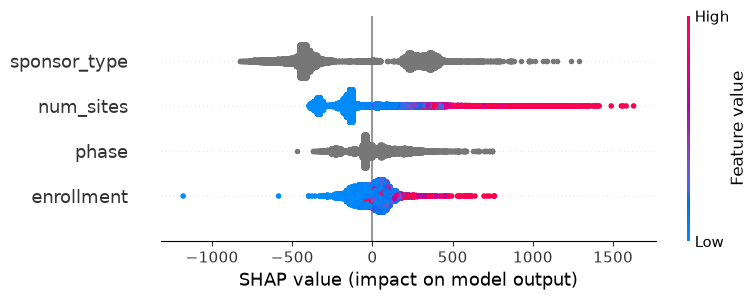

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)